In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [24]:
df = pd.read_csv("../heart_cleaned.csv")

In [25]:
df_cluster = df.copy()

In [26]:
df_cluster = df_cluster.drop( columns= ["country", "target", "ca"])

In [27]:
df_cluster["slope"] = df_cluster["slope"].fillna(0)
df_cluster["thal"] = df_cluster["thal"].fillna(0)

In [28]:
df_cluster = pd.get_dummies(df_cluster, drop_first= True)

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

In [30]:
X_scaled.shape

(918, 13)

Choosing the Number of Clusters

Before applying K-Means clustering, the optimal number of clusters should be explored.

The Elbow Method is used to evaluate how the within-cluster variation changes as the number of clusters increases.

In [31]:
inertia = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters= k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

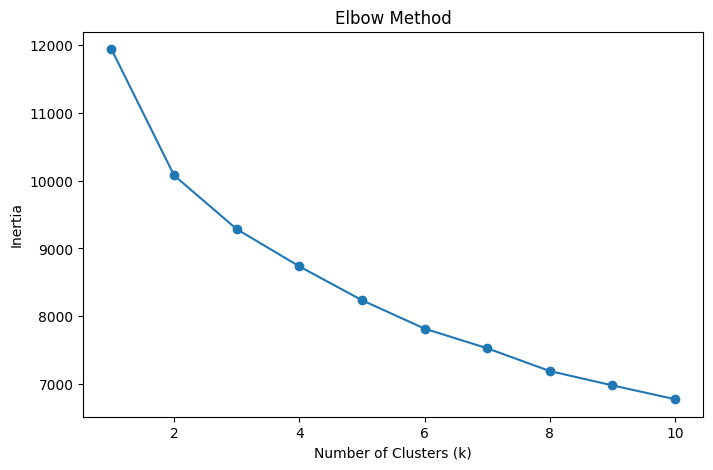

In [32]:
plt.figure(figsize=(8,5))
plt.plot(
    range(1,11),
    inertia,
    marker = "o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [33]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"k ={k}: {score: .3f}")

k =2:  0.157
k =3:  0.161
k =4:  0.150
k =5:  0.123
k =6:  0.128
k =7:  0.126
k =8:  0.118
k =9:  0.115
k =10:  0.123


Selecting the Number of Clusters

The Elbow Method suggested a possible elbow around 3–4 clusters.

To support the choice, silhouette scores were calculated for different values of k.

The highest silhouette score was obtained for k = 3 (0.161).

Although the score is relatively low, indicating that the clusters are not strongly separated, k = 3 provides the best balance between cluster compactness and separation.

Therefore, three clusters were selected for the subsequent analysis.